=== [1/5] Carte de référence (corrélation classique) ===
  100%


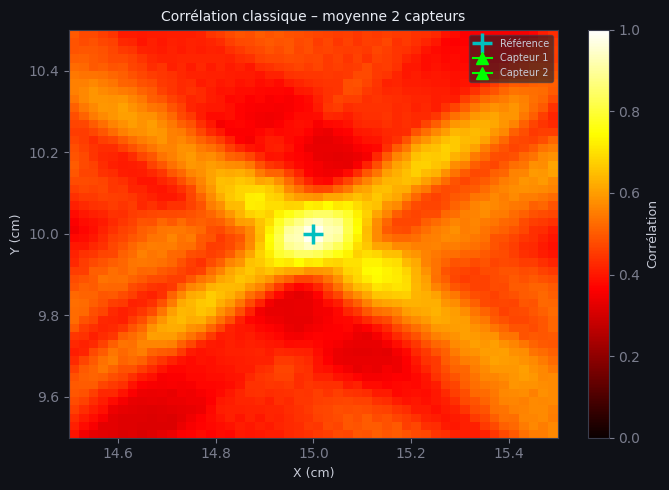


=== [2/5] Influence de la fréquence centrale (fc_test) ===
  fc_test = 1 MHz ...
  100%
  fc_test = 2 MHz (ref) ...
  100%
  fc_test = 3 MHz ...
  100%
  fc_test = 4 MHz ...
  100%


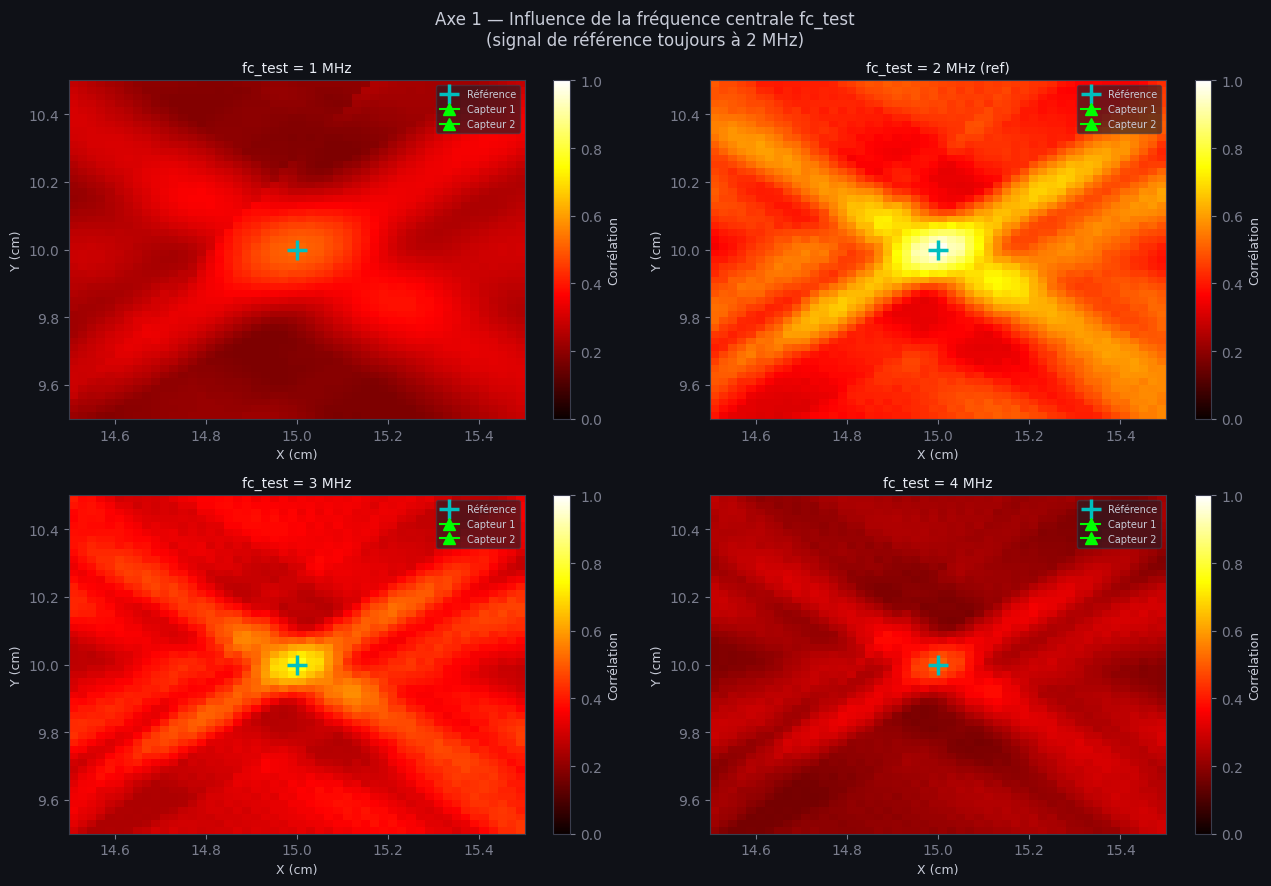


=== [3/5] Corrélation de phase vs classique ===
  100%


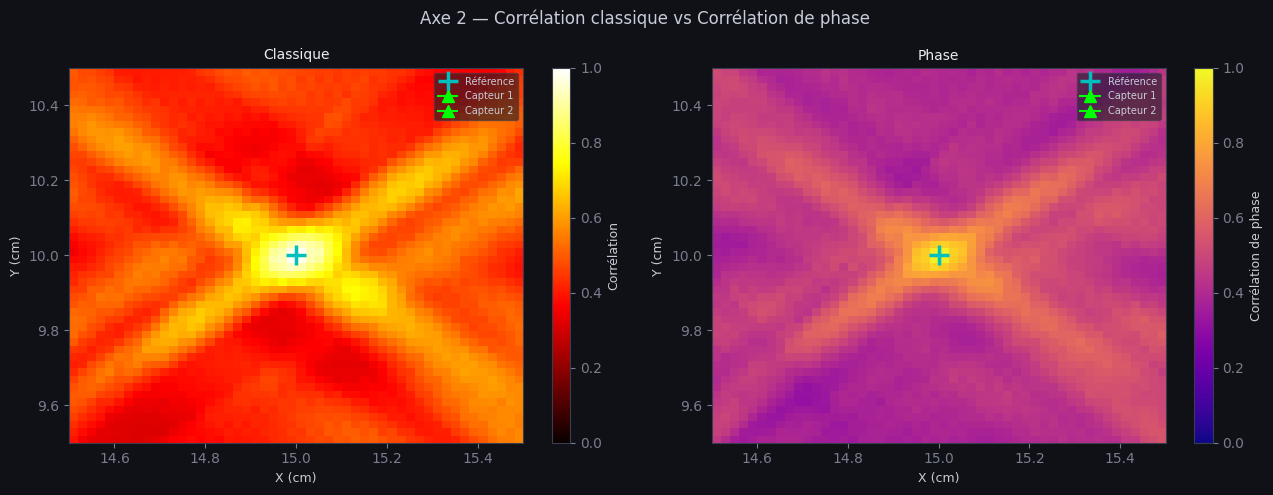


=== [4/5] Influence de l'ordre max ===
  ordre_max = 1 ...
  100%
  ordre_max = 2 ...
  100%
  ordre_max = 3 ...
  100%
  ordre_max = 4 ...
  100%


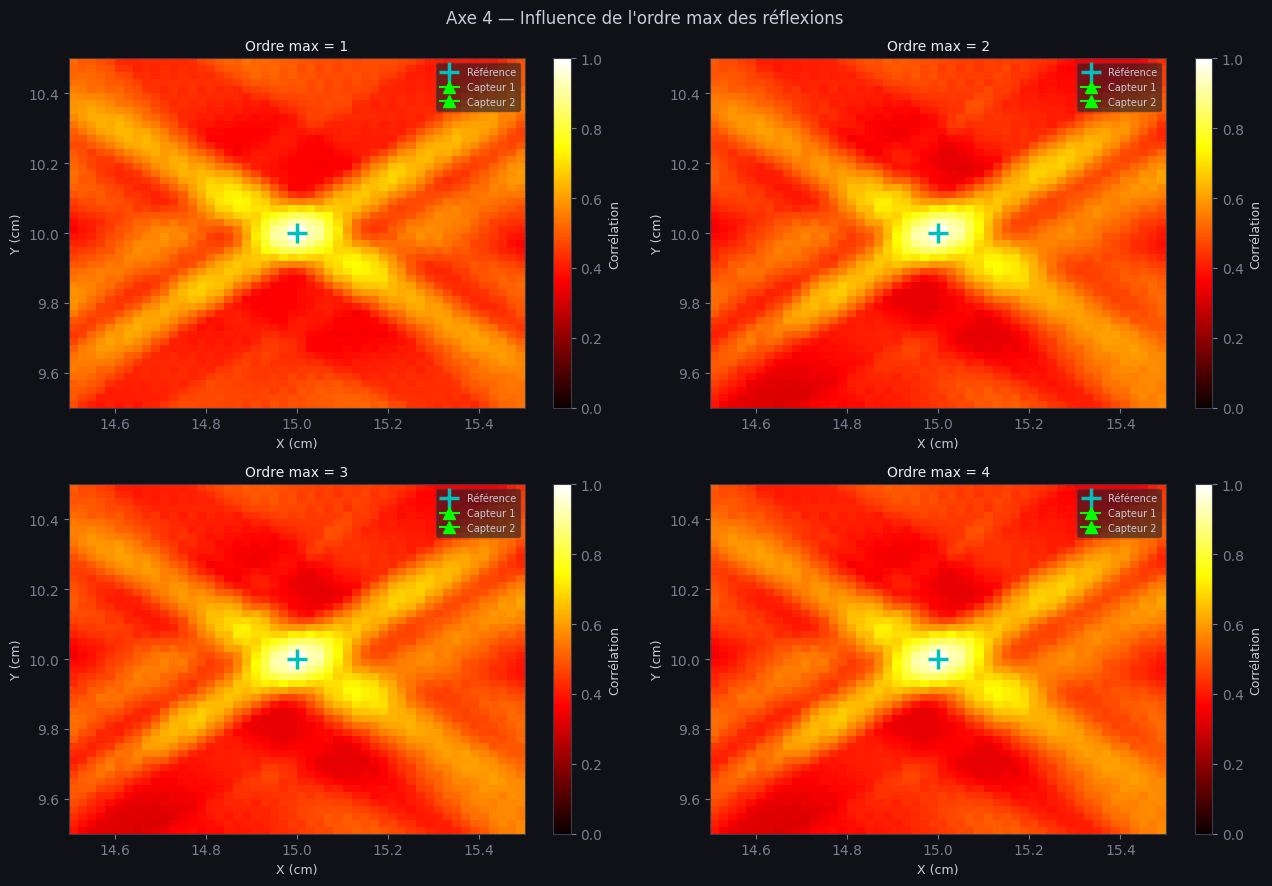


=== [5/5] Robustesse au bruit ===
  SNR = 30 dB  (sigma = 0.0056) ...
  100%
  SNR = 20 dB  (sigma = 0.0177) ...
  100%
  SNR = 10 dB  (sigma = 0.0561) ...
  100%
  SNR = 5 dB  (sigma = 0.0997) ...
  100%


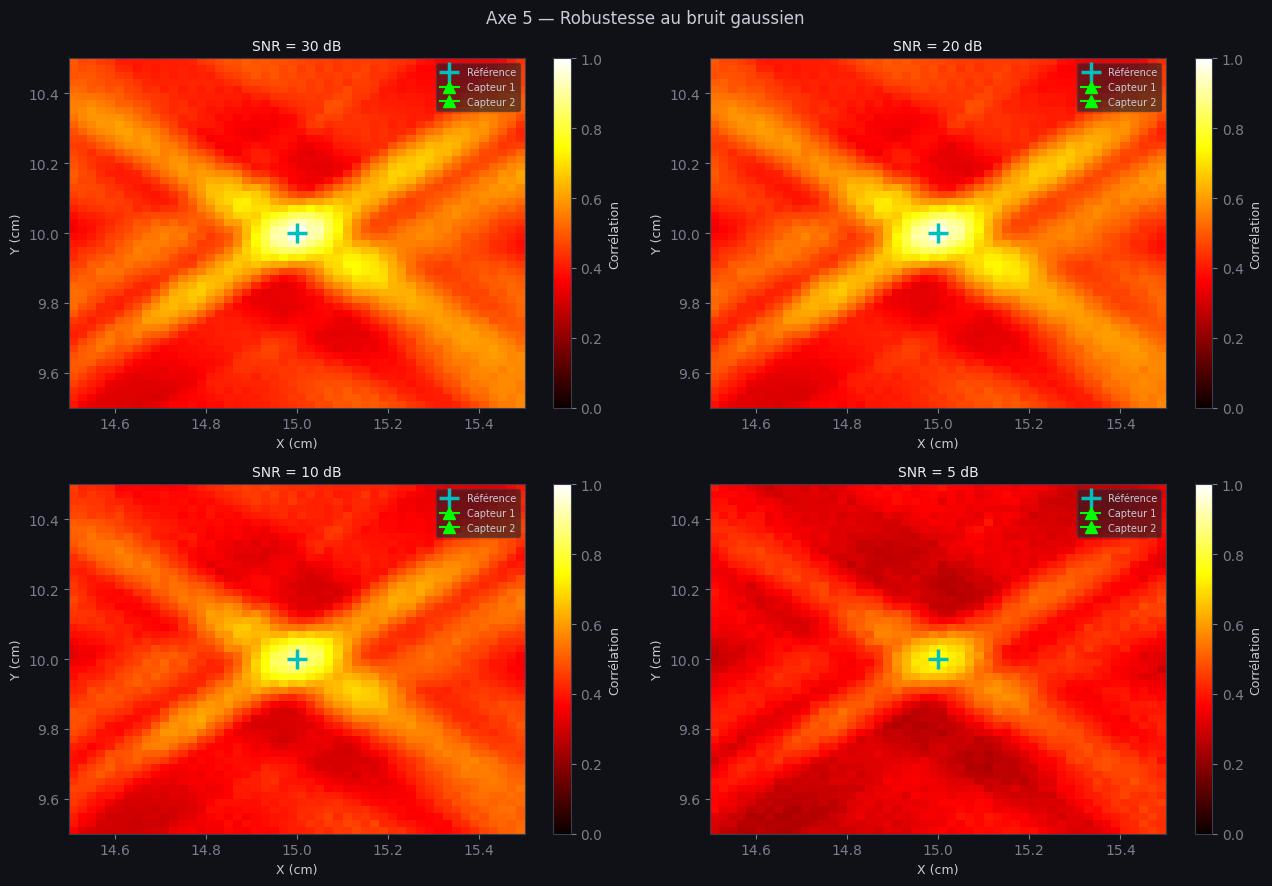


=== GÉNÉRATION DES CARTES MULTI-ÉCHELLES (ZOOM PROGRESSIF) ===
Cette étape utilise la corrélation de phase, réputée plus précise.

Calcul de la carte 1/3 : 1. Balayage Global...
  100%

Calcul de la carte 2/3 : 2. Rapprochement...
  100%

Calcul de la carte 3/3 : 3. Localisation Fine...
  100%


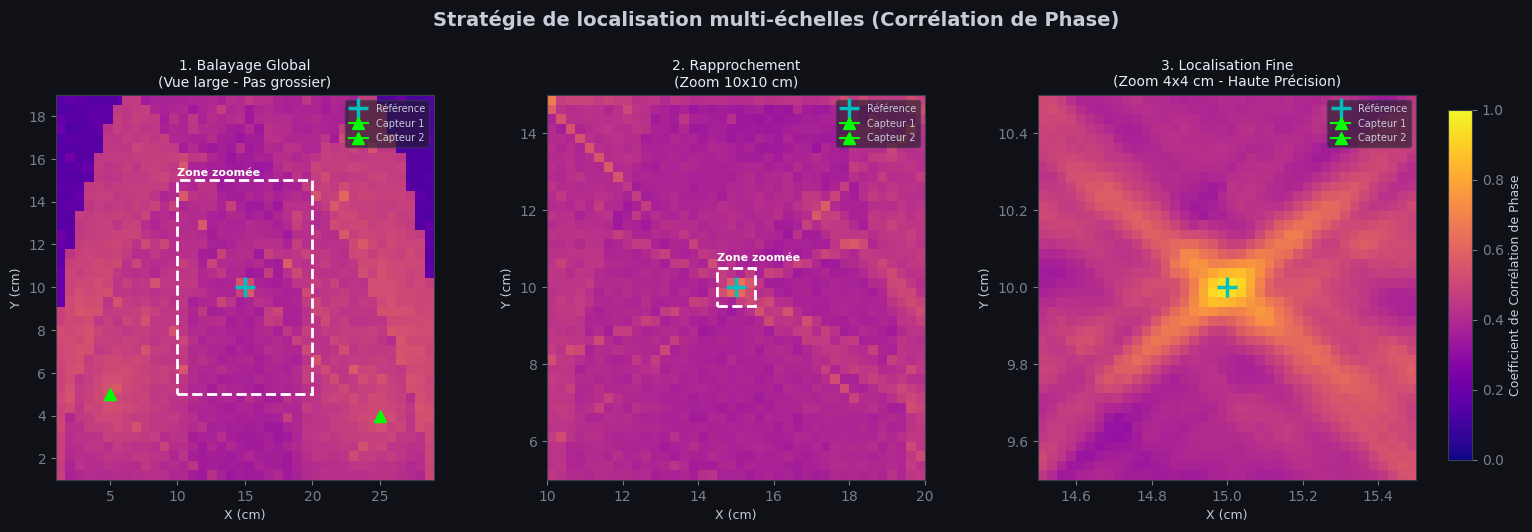

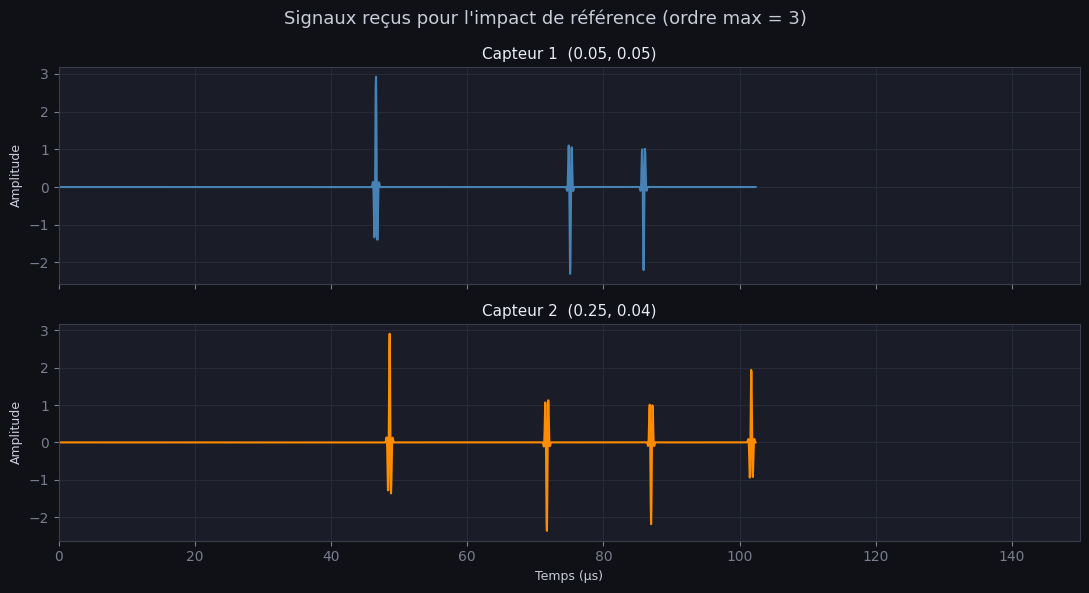

Calcul du profil de corrélation 1D sur l'axe X ...


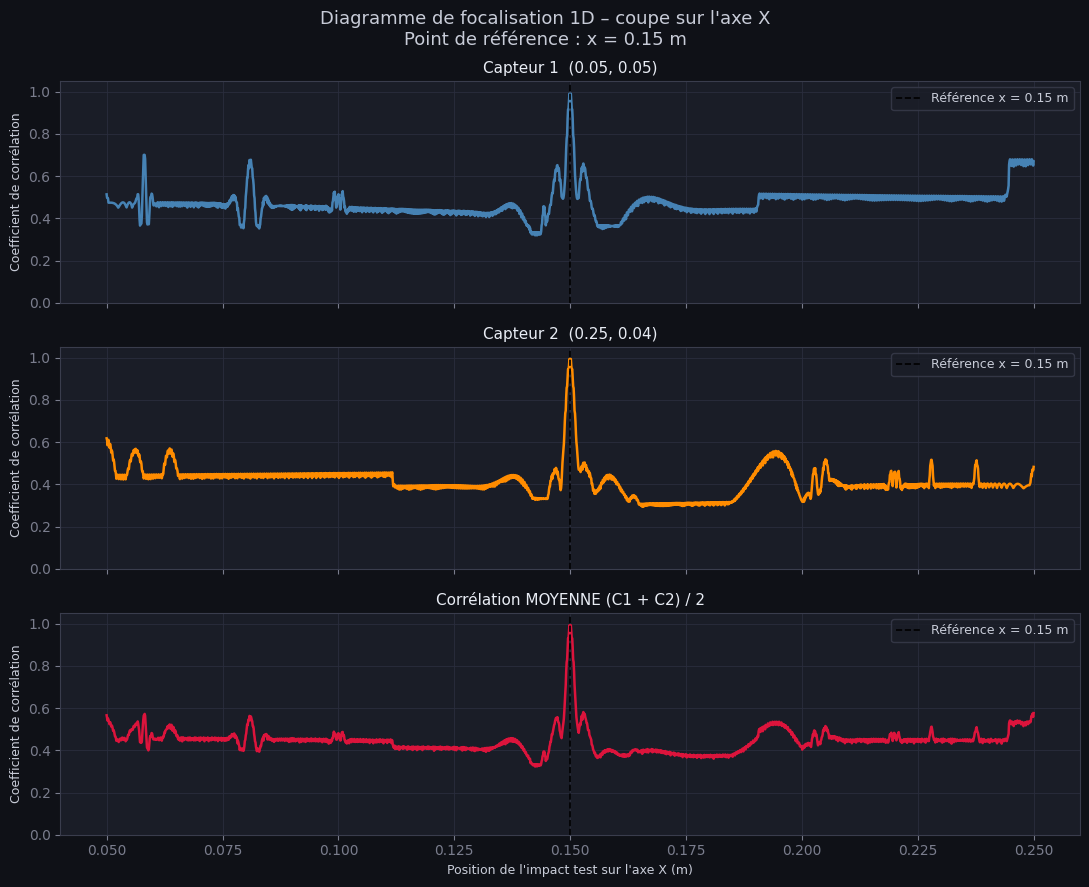

Terminé.
Initialisation du système avec 3 capteurs et grille haute résolution...

 Évaluation sur 30 impacts en cours...
    [ 1/30] err=5.57 cm
    [ 2/30] err=0.00 cm
    [ 3/30] err=0.00 cm
    [ 4/30] err=0.00 cm
    [ 5/30] err=0.00 cm
    [ 6/30] err=0.00 cm
    [ 7/30] err=0.00 cm
    [ 8/30] err=0.00 cm
    [ 9/30] err=0.00 cm
    [10/30] err=0.93 cm
    [11/30] err=0.00 cm
    [12/30] err=0.23 cm
    [13/30] err=0.00 cm
    [14/30] err=0.00 cm
    [15/30] err=0.00 cm
    [16/30] err=0.00 cm
    [17/30] err=0.00 cm
    [18/30] err=0.00 cm
    [19/30] err=0.00 cm
    [20/30] err=0.39 cm
    [21/30] err=6.81 cm
    [22/30] err=0.00 cm
    [23/30] err=0.18 cm
    [24/30] err=3.03 cm
    [25/30] err=0.00 cm
    [26/30] err=0.00 cm
    [27/30] err=0.00 cm
    [28/30] err=0.00 cm
    [29/30] err=0.11 cm
    [30/30] err=2.39 cm

 ✓ Erreur moyenne : 0.65 cm (P90=2.45 cm)


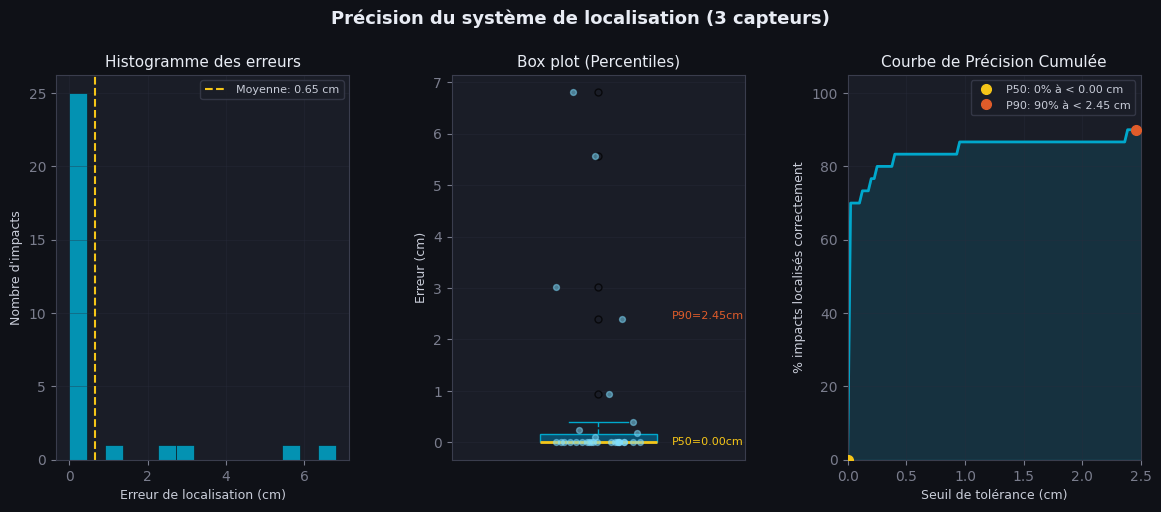

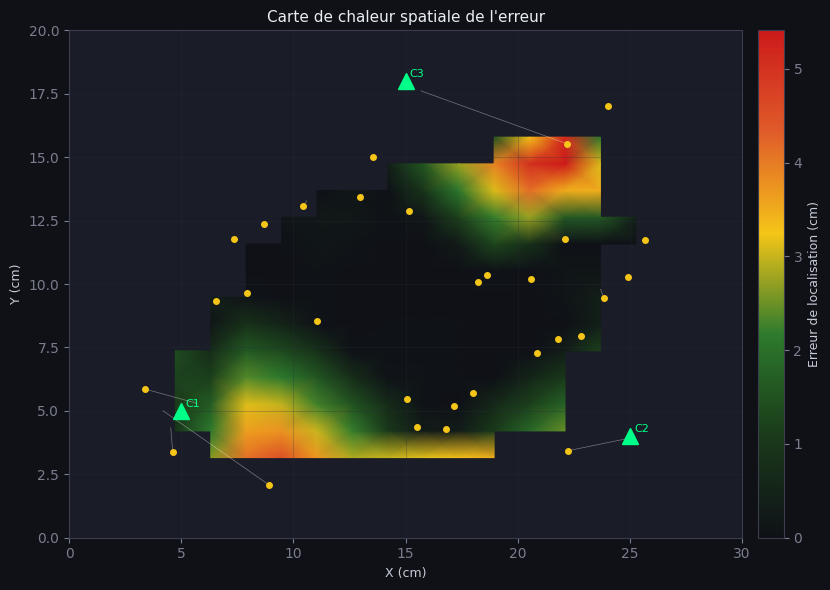

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import gausspulse
from scipy.optimize import minimize
from scipy.interpolate import griddata
from dataclasses import dataclass, field
from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)  #Cela crée une variabilité dans nos résultats c'est pour cela que l'on a une légère différence entre les graphes du compte-rendu et ceux généré avec ce code qui réunit toute les parties du projet

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#c8ccd8',
    'axes.titlecolor'  : '#e8ecf4',
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 9,
    'xtick.color'      : '#7a7d8d',
    'ytick.color'      : '#7a7d8d',
    'grid.color'       : '#2a2d3d',
    'grid.linewidth'   : 0.6,
    'text.color'       : '#c8ccd8',
    'legend.facecolor' : '#1a1d27',
    'legend.edgecolor' : '#3a3d4d',
    'legend.fontsize'  : 8,
})

CMAP_ERR = LinearSegmentedColormap.from_list('error',
    ['#0f1117', '#1a3a1a', '#2d7a2d', '#f5c518', '#e05c2a', '#cc1a1a'])


# =============================================================================
#  DATA CLASSES
# =============================================================================

@dataclass
class ResultatLocalisation:
    pos_reelle     : Tuple[float, float]
    pos_detectee   : Tuple[float, float]
    erreur_cm      : float
    correlation_max: float

@dataclass
class RapportEvaluation:
    resultats      : List[ResultatLocalisation] = field(default_factory=list)
    n_impacts      : int   = 0
    erreur_mean_cm : float = 0.0
    erreur_std_cm  : float = 0.0
    erreur_p50_cm  : float = 0.0
    erreur_p90_cm  : float = 0.0
    erreur_p95_cm  : float = 0.0


# =============================================================================
#  CLASSE PRINCIPALE
# =============================================================================

class PlaqueTactile:
    def __init__(self, fc: float = 2e6, n_points: int = 2048,
                 capteurs: List[Tuple[float, float]] = None):
        self.a  = 0.30
        self.b  = 0.20
        self.v  = 2400.0
        self.fs = 20e6
        self.fc = fc
        self.bw = 1.0
        self.N  = n_points
        self.t  = np.arange(self.N) / self.fs

        self.capteurs = capteurs if capteurs is not None else [
            (0.05, 0.05),
            (0.25, 0.04),
        ]

    def sources_images(self, pos_source: Tuple[float, float],
                       pos_capteur: Tuple[float, float],
                       ordre_max: int = 3) -> List[Tuple[float, float]]:
        xs, ys = pos_source
        xc, yc = pos_capteur
        impulsions = []
        for i in range(-ordre_max, ordre_max + 1):
            for j in range(-ordre_max, ordre_max + 1):
                if abs(i) + abs(j) > ordre_max:
                    continue
                x_img = i * self.a + xs if i % 2 == 0 else (i + 1) * self.a - xs
                y_img = j * self.b + ys if j % 2 == 0 else (j + 1) * self.b - ys
                signe = (-1) ** (abs(i) + abs(j))
                dist  = np.hypot(x_img - xc, y_img - yc)
                if dist > 0:
                    impulsions.append((dist / self.v, signe / np.sqrt(dist)))
        return impulsions

    def signal_recu(self, pos_source: Tuple[float, float],
                    pos_capteur: Tuple[float, float],
                    ordre_max: int = 3,
                    fc_override: float = None,
                    bruit_sigma: float = 0.0) -> np.ndarray:
        fc_use     = fc_override if fc_override is not None else self.fc
        impulsions = self.sources_images(pos_source, pos_capteur, ordre_max)
        s = np.zeros(self.N)
        for t_arr, amp in impulsions:
            if t_arr < self.N / self.fs:
                s += amp * gausspulse(self.t - t_arr, fc=fc_use, bw=self.bw)
        if bruit_sigma > 0:
            s += np.random.normal(0, bruit_sigma, self.N)
        return s

    def energie(self, s: np.ndarray) -> float:
        return float(np.sum(s ** 2))

    def correlation(self, s1: np.ndarray, s2: np.ndarray) -> float:
        e1, e2 = self.energie(s1), self.energie(s2)
        if e1 == 0 or e2 == 0:
            return 0.0
        conv = np.fft.ifft(np.fft.fft(s1[::-1]) * np.fft.fft(s2))
        return float(np.real((1.0 / np.sqrt(e1 * e2)) * np.max(np.abs(conv))))

    def correlation_phase(self, s1: np.ndarray, s2: np.ndarray,
                          seuil_relatif: float = 0.05) -> float:
        S1, S2   = np.fft.fft(s1), np.fft.fft(s2)
        amp1, amp2 = np.abs(S1), np.abs(S2)
        masque   = (amp1 > seuil_relatif * np.max(amp1)) & \
                   (amp2 > seuil_relatif * np.max(amp2))
        M = masque.sum()
        if M == 0:
            return 0.0
        S1_ph = np.where(masque, S1 / (amp1 + 1e-30), 0)
        S2_ph = np.where(masque, S2 / (amp2 + 1e-30), 0)
        conv  = np.fft.ifft(np.conj(S1_ph) * S2_ph)
        return float(np.real(np.max(np.abs(conv))) / (M / len(s1)))

    def grille_2d(self, pos_ref: Tuple[float, float],
                  x_range: np.ndarray, y_range: np.ndarray,
                  ordre_max: int = 3, fc_test: float = None,
                  methode: str = 'classique',
                  bruit_sigma: float = 0.0) -> np.ndarray:
        NX, NY  = len(x_range), len(y_range)
        CMoy    = np.zeros((NY, NX))
        sig_ref = [self.signal_recu(pos_ref, cap, ordre_max) for cap in self.capteurs]
        corr_fn = self.correlation_phase if methode == 'phase' else self.correlation

        for jj, y in enumerate(y_range):
            for ii, x in enumerate(x_range):
                c_vals = []
                for k, cap in enumerate(self.capteurs):
                    s_ref  = sig_ref[k].copy()
                    s_test = self.signal_recu((x, y), cap, ordre_max,
                                             fc_override=fc_test)
                    if bruit_sigma > 0:
                        s_ref  += np.random.normal(0, bruit_sigma, self.N)
                        s_test += np.random.normal(0, bruit_sigma, self.N)
                    c_vals.append(corr_fn(s_ref, s_test))
                CMoy[jj, ii] = np.mean(c_vals)
            print(f"  {int(100*(jj+1)/NY):3d}%", end='\r')
        print()
        return CMoy

    def correlation_moyenne_phase(self, sig_ref: List[np.ndarray],
                                   pos_test: Tuple[float, float],
                                   ordre_max: int = 3) -> float:
        return float(np.mean([
            self.correlation_phase(sig_ref[k],
                                   self.signal_recu(pos_test, cap, ordre_max))
            for k, cap in enumerate(self.capteurs)
        ]))


# =============================================================================
#  UTILITAIRES D'AFFICHAGE
# =============================================================================

def afficher_carte(ax, carte, x_range, y_range, capteurs, pos_ref,
                   titre='', cmap='hot'):
    x_min, x_max = x_range[0] * 100, x_range[-1] * 100
    y_min, y_max = y_range[0] * 100, y_range[-1] * 100

    im = ax.imshow(carte, extent=[x_min, x_max, y_min, y_max],
                   origin='lower', aspect='auto', cmap=cmap, vmin=0, vmax=1)

    ax.plot(pos_ref[0] * 100, pos_ref[1] * 100,
            'c+', markersize=14, markeredgewidth=2.5, label='Référence')
    for idx, cap in enumerate(capteurs):
        ax.plot(cap[0] * 100, cap[1] * 100,
                marker='^', color='lime', markersize=9, label=f'Capteur {idx+1}')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(titre, fontsize=10)
    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.legend(fontsize=7, loc='upper right', framealpha=0.6)
    return im


# =============================================================================
#  LOCALISATEUR
# =============================================================================

class Localisateur:
    def __init__(self, plaque: PlaqueTactile,
                 nx: int = 80, ny: int = 55, ordre_max: int = 3):
        self.plaque     = plaque
        self.ordre_max  = ordre_max
        self.x_grid     = np.linspace(0.01, plaque.a - 0.01, nx)
        self.y_grid     = np.linspace(0.01, plaque.b - 0.01, ny)

    def localiser(self, sig_ref: List[np.ndarray]) -> Tuple[Tuple[float, float], float]:
        C = np.array([[
            self.plaque.correlation_moyenne_phase(sig_ref, (x, y), self.ordre_max)
            for x in self.x_grid]
            for y in self.y_grid])

        j_max, i_max = np.unravel_index(np.argmax(C), C.shape)
        c_max = C[j_max, i_max]
        x0, y0 = self.x_grid[i_max], self.y_grid[j_max]

        def objectif(xy):
            x, y = xy
            if not (0 < x < self.plaque.a and 0 < y < self.plaque.b):
                return 1.0
            return -self.plaque.correlation_moyenne_phase(sig_ref, (x, y), self.ordre_max)

        res   = minimize(objectif, x0=[x0, y0], method='Nelder-Mead',
                         options={'xatol': 1e-4, 'fatol': 1e-5, 'maxiter': 200})
        x_fin = float(np.clip(res.x[0], 0.01, self.plaque.a - 0.01))
        y_fin = float(np.clip(res.x[1], 0.01, self.plaque.b - 0.01))
        c_fin = -float(res.fun)

        return (x_fin, y_fin), max(c_max, c_fin)


# =============================================================================
#  ÉVALUATEUR
# =============================================================================

class Evaluateur:
    def __init__(self, plaque: PlaqueTactile, localisateur: Localisateur,
                 ordre_max: int = 3, bruit_sigma: float = 0.0):
        self.plaque       = plaque
        self.localisateur = localisateur
        self.ordre_max    = ordre_max
        self.bruit_sigma  = bruit_sigma

    def generer_impacts(self, n: int, marge: float = 0.02) -> List[Tuple[float, float]]:
        xs = np.random.uniform(marge, self.plaque.a - marge, n)
        ys = np.random.uniform(marge, self.plaque.b - marge, n)
        return list(zip(xs, ys))

    def evaluer(self, n_impacts: int = 30) -> RapportEvaluation:
        impacts = self.generer_impacts(n_impacts)
        rapport = RapportEvaluation(n_impacts=n_impacts)
        erreurs = []

        print(f"\n Évaluation sur {n_impacts} impacts en cours...")
        for k, pos_reelle in enumerate(impacts):
            sig_ref = [
                self.plaque.signal_recu(pos_reelle, cap, self.ordre_max, bruit_sigma=self.bruit_sigma)
                for cap in self.plaque.capteurs
            ]
            pos_det, c_max = self.localisateur.localiser(sig_ref)
            err_cm = np.hypot(pos_det[0] - pos_reelle[0], pos_det[1] - pos_reelle[1]) * 100
            erreurs.append(err_cm)
            rapport.resultats.append(ResultatLocalisation(
                pos_reelle=pos_reelle, pos_detectee=pos_det,
                erreur_cm=err_cm, correlation_max=c_max))
            print(f"    [{k+1:2d}/{n_impacts}] err={err_cm:.2f} cm")

        erreurs_arr           = np.array(erreurs)
        rapport.erreur_mean_cm = float(np.mean(erreurs_arr))
        rapport.erreur_std_cm  = float(np.std(erreurs_arr))
        rapport.erreur_p50_cm  = float(np.percentile(erreurs_arr, 50))
        rapport.erreur_p90_cm  = float(np.percentile(erreurs_arr, 90))
        rapport.erreur_p95_cm  = float(np.percentile(erreurs_arr, 95))
        print(f"\n ✓ Erreur moyenne : {rapport.erreur_mean_cm:.2f} cm (P90={rapport.erreur_p90_cm:.2f} cm)")
        return rapport

    def courbe_roc_precision(self, rapport: RapportEvaluation,
                              seuils: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        erreurs = np.array([r.erreur_cm for r in rapport.resultats])
        taux    = np.array([np.mean(erreurs <= d) for d in seuils])
        return seuils, taux

    def carte_erreur_spatiale(self, rapport: RapportEvaluation,
                               resolution: int = 20) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        pts  = np.array([r.pos_reelle for r in rapport.resultats])
        errs = np.array([r.erreur_cm  for r in rapport.resultats])
        xi   = np.linspace(0, self.plaque.a, resolution)
        yi   = np.linspace(0, self.plaque.b, resolution)
        XI, YI = np.meshgrid(xi, yi)
        ZI = griddata(pts, errs, (XI, YI), method='linear')
        return XI, YI, ZI


# =============================================================================
#  FONCTIONS DE VISUALISATION (parties 3 et 4)
# =============================================================================

def figure_distribution_erreurs(rapport, seuils_d, taux_roc):
    erreurs = np.array([r.erreur_cm for r in rapport.resultats])
    fig     = plt.figure(figsize=(14, 5), facecolor='#0f1117')
    fig.suptitle("Précision du système de localisation (3 capteurs)",
                 color='#e8ecf4', fontsize=13, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    ax1 = fig.add_subplot(gs[0])
    ax1.hist(erreurs, bins=min(15, max(5, len(erreurs) // 2)),
             color='#00a8cc', edgecolor='#0f1117', linewidth=0.5, alpha=0.85)
    ax1.axvline(rapport.erreur_mean_cm, color='#f5c518', lw=1.5, linestyle='--',
                label=f'Moyenne: {rapport.erreur_mean_cm:.2f} cm')
    ax1.set_xlabel("Erreur de localisation (cm)")
    ax1.set_ylabel("Nombre d'impacts")
    ax1.set_title("Histogramme des erreurs")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.4)

    ax2 = fig.add_subplot(gs[1])
    ax2.boxplot(erreurs, vert=True, patch_artist=True, widths=0.4,
                medianprops  =dict(color='#f5c518', linewidth=2),
                boxprops     =dict(facecolor='#0a4f6e', color='#00a8cc'),
                whiskerprops =dict(color='#00a8cc', linestyle='--'),
                capprops     =dict(color='#00a8cc'),
                flierprops   =dict(marker='o', color='#e05c2a', markersize=5, alpha=0.7))
    ax2.scatter(np.ones(len(erreurs)) + np.random.uniform(-0.15, 0.15, len(erreurs)),
                erreurs, color='#7fdeff', alpha=0.5, s=18, zorder=3)
    ax2.set_ylabel("Erreur (cm)")
    ax2.set_title("Box plot (Percentiles)")
    ax2.set_xticks([])
    ax2.grid(True, alpha=0.4, axis='y')
    for val, lbl, col in [(rapport.erreur_p50_cm, 'P50', '#f5c518'),
                           (rapport.erreur_p90_cm, 'P90', '#e05c2a')]:
        ax2.annotate(f'{lbl}={val:.2f}cm', xy=(1.25, val), fontsize=8, color=col, va='center')

    ax3 = fig.add_subplot(gs[2])
    ax3.plot(seuils_d, taux_roc * 100, color='#00a8cc', lw=2)
    ax3.fill_between(seuils_d, taux_roc * 100, alpha=0.15, color='#00a8cc')
    for val, col, lbl in [(rapport.erreur_p50_cm, '#f5c518', 'P50'),
                           (rapport.erreur_p90_cm, '#e05c2a', 'P90')]:
        idx = np.argmin(np.abs(seuils_d - val))
        ax3.plot(seuils_d[idx], taux_roc[idx] * 100, 'o', color=col,
                 markersize=7, zorder=5,
                 label=f'{lbl}: {taux_roc[idx]*100:.0f}% à < {val:.2f} cm')
    ax3.set_xlabel("Seuil de tolérance (cm)")
    ax3.set_ylabel("% impacts localisés correctement")
    ax3.set_title("Courbe de Précision Cumulée")
    ax3.set_xlim(0, max(2.0, seuils_d[-1] / 2))
    ax3.set_ylim(0, 105)
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.4)

    plt.tight_layout()
    return fig


def figure_carte_erreur(XI, YI, ZI, rapport, plaque):
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='#0f1117')
    ax.set_facecolor('#1a1d27')

    im = ax.pcolormesh(XI * 100, YI * 100, ZI, cmap=CMAP_ERR, shading='gouraud', vmin=0)
    cb = plt.colorbar(im, ax=ax, pad=0.02)
    cb.set_label("Erreur de localisation (cm)", color='#c8ccd8')

    for idx, cap in enumerate(plaque.capteurs):
        ax.plot(cap[0]*100, cap[1]*100, '^', color='#00ff88', markersize=11, zorder=6)
        ax.annotate(f'C{idx+1}', xy=(cap[0]*100, cap[1]*100),
                    xytext=(3, 3), textcoords='offset points', fontsize=8, color='#00ff88')

    for r in rapport.resultats:
        xr, yr = r.pos_reelle[0]*100,   r.pos_reelle[1]*100
        xd, yd = r.pos_detectee[0]*100, r.pos_detectee[1]*100
        ax.plot(xr, yr, 'o', color='#f5c518', markersize=4, zorder=5)
        ax.plot([xr, xd], [yr, yd], '-', color='#ffffff', lw=0.5, alpha=0.4, zorder=4)

    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_title("Carte de chaleur spatiale de l'erreur", color='#e8ecf4')
    ax.set_xlim(0, plaque.a * 100)
    ax.set_ylim(0, plaque.b * 100)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


# =============================================================================
#  PROGRAMME PRINCIPAL
# =============================================================================

ORDRE   = 3
pos_ref = (0.15, 0.10)

# Grille commune pour les parties 1 et 2
NX, NY  = 50, 50
x_range = np.linspace(0.145, 0.155, NX)
y_range = np.linspace(0.095, 0.105, NY)

# Instance unique avec 2 capteurs (parties 1, 2, 3)
plaque2 = PlaqueTactile(fc=2e6, n_points=2048)

# Instance avec 3 capteurs + fenêtre plus large (partie 4)
plaque3 = PlaqueTactile(fc=2e6, n_points=4096, capteurs=[
    (0.05, 0.05),
    (0.25, 0.04),
    (0.15, 0.18),
])


# ─────────────────────────────────────────────────────────────
# PARTIE 1 — Cartes de corrélation : classique, fréquence, phase, ordre, bruit
# ─────────────────────────────────────────────────────────────

print("=== [1/5] Carte de référence (corrélation classique) ===")
C_ref = plaque2.grille_2d(pos_ref, x_range, y_range, ordre_max=ORDRE)

fig1, ax = plt.subplots(figsize=(7, 5))
im = afficher_carte(ax, C_ref, x_range, y_range, plaque2.capteurs, pos_ref,
                    titre="Corrélation classique – moyenne 2 capteurs")
plt.colorbar(im, ax=ax, label='Corrélation')
plt.tight_layout()
plt.show()

print("\n=== [2/5] Influence de la fréquence centrale (fc_test) ===")
freqs_test  = [1e6, 2e6, 3e6, 4e6]
labels_freq = ['1 MHz', '2 MHz (ref)', '3 MHz', '4 MHz']

fig2, axes2 = plt.subplots(2, 2, figsize=(13, 9))
fig2.suptitle("Axe 1 — Influence de la fréquence centrale fc_test\n"
              "(signal de référence toujours à 2 MHz)", fontsize=12)

for ax, fc_t, lbl in zip(axes2.flat, freqs_test, labels_freq):
    print(f"  fc_test = {lbl} ...")
    C  = plaque2.grille_2d(pos_ref, x_range, y_range, ordre_max=ORDRE, fc_test=fc_t)
    im = afficher_carte(ax, C, x_range, y_range, plaque2.capteurs, pos_ref,
                        titre=f"fc_test = {lbl}")
    plt.colorbar(im, ax=ax, label='Corrélation')

plt.tight_layout()
plt.show()

print("\n=== [3/5] Corrélation de phase vs classique ===")
C_phase = plaque2.grille_2d(pos_ref, x_range, y_range, ordre_max=ORDRE, methode='phase')

fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Axe 2 — Corrélation classique vs Corrélation de phase", fontsize=12)

im3a = afficher_carte(ax3a, C_ref, x_range, y_range, plaque2.capteurs, pos_ref,
                      titre="Classique")
plt.colorbar(im3a, ax=ax3a, label='Corrélation')

im3b = afficher_carte(ax3b, C_phase, x_range, y_range, plaque2.capteurs, pos_ref,
                      titre="Phase", cmap='plasma')
plt.colorbar(im3b, ax=ax3b, label='Corrélation de phase')

plt.tight_layout()
plt.show()

print("\n=== [4/5] Influence de l'ordre max ===")
ordres = [1, 2, 3, 4]

fig4, axes4 = plt.subplots(2, 2, figsize=(13, 9))
fig4.suptitle("Axe 4 — Influence de l'ordre max des réflexions", fontsize=12)

for ax, ord_max in zip(axes4.flat, ordres):
    print(f"  ordre_max = {ord_max} ...")
    C  = plaque2.grille_2d(pos_ref, x_range, y_range, ordre_max=ord_max)
    im = afficher_carte(ax, C, x_range, y_range, plaque2.capteurs, pos_ref,
                        titre=f"Ordre max = {ord_max}")
    plt.colorbar(im, ax=ax, label='Corrélation')

plt.tight_layout()
plt.show()

print("\n=== [5/5] Robustesse au bruit ===")
sig_exemple = plaque2.signal_recu(pos_ref, plaque2.capteurs[0], ORDRE)
E_ref       = np.sqrt(plaque2.energie(sig_exemple) / plaque2.N)

snr_list   = [30, 20, 10, 5]
sigma_list = [E_ref / (10 ** (snr / 20)) for snr in snr_list]

fig5, axes5 = plt.subplots(2, 2, figsize=(13, 9))
fig5.suptitle("Axe 5 — Robustesse au bruit gaussien", fontsize=12)

for ax, snr, sigma in zip(axes5.flat, snr_list, sigma_list):
    print(f"  SNR = {snr} dB  (sigma = {sigma:.4f}) ...")
    C  = plaque2.grille_2d(pos_ref, x_range, y_range, ordre_max=ORDRE, bruit_sigma=sigma)
    im = afficher_carte(ax, C, x_range, y_range, plaque2.capteurs, pos_ref,
                        titre=f"SNR = {snr} dB")
    plt.colorbar(im, ax=ax, label='Corrélation')

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# PARTIE 2 — Approche multi-échelles (zooms progressifs)
# ─────────────────────────────────────────────────────────────

print("\n=== GÉNÉRATION DES CARTES MULTI-ÉCHELLES (ZOOM PROGRESSIF) ===")
print("Cette étape utilise la corrélation de phase, réputée plus précise.")

zooms = [
    {"x": np.linspace(0.01,  0.29, 40), "y": np.linspace(0.01,  0.19, 40),
     "titre": "1. Balayage Global\n(Vue large - Pas grossier)"},
    {"x": np.linspace(0.10,  0.20, 40), "y": np.linspace(0.05,  0.15, 40),
     "titre": "2. Rapprochement\n(Zoom 10x10 cm)"},
    {"x": np.linspace(0.145, 0.155, 40), "y": np.linspace(0.095, 0.105, 40),
     "titre": "3. Localisation Fine\n(Zoom 4x4 cm - Haute Précision)"},
]

cartes_zoom = []
for i, zoom in enumerate(zooms):
    print(f"\nCalcul de la carte {i+1}/3 : {zoom['titre'].split(chr(10))[0]}...")
    C = plaque2.grille_2d(pos_ref, zoom["x"], zoom["y"], ordre_max=ORDRE, methode='phase')
    cartes_zoom.append(C)

fig_z, axes_z = plt.subplots(1, 3, figsize=(16, 5))
fig_z.suptitle("Stratégie de localisation multi-échelles (Corrélation de Phase)",
               fontsize=14, fontweight='bold', y=1.05)

for i, (ax, zoom, carte) in enumerate(zip(axes_z, zooms, cartes_zoom)):
    im = afficher_carte(ax, carte, zoom["x"], zoom["y"],
                        plaque2.capteurs, pos_ref,
                        titre=zoom["titre"], cmap='plasma')
    if i < 2:
        next_z  = zooms[i + 1]
        rect_x  = next_z["x"][0]  * 100
        rect_y  = next_z["y"][0]  * 100
        rect_w  = (next_z["x"][-1] - next_z["x"][0])  * 100
        rect_h  = (next_z["y"][-1] - next_z["y"][0])  * 100
        rect    = patches.Rectangle((rect_x, rect_y), rect_w, rect_h,
                                     linewidth=2, edgecolor='white',
                                     facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(rect_x, rect_y + rect_h + 0.2, "Zone zoomée",
                color='white', fontsize=8, fontweight='bold')

cbar_ax = fig_z.add_axes([0.92, 0.15, 0.015, 0.7])
fig_z.colorbar(im, cax=cbar_ax, label="Coefficient de Corrélation de Phase")
plt.subplots_adjust(left=0.05, right=0.90, wspace=0.3)
plt.show()


# ─────────────────────────────────────────────────────────────
# PARTIE 3 — Signaux temporels et diagramme 1D
# ─────────────────────────────────────────────────────────────

fig_s, axes_s = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
fig_s.suptitle("Signaux reçus pour l'impact de référence (ordre max = 3)", fontsize=13)

for idx, capteur in enumerate(plaque2.capteurs):
    sig = plaque2.signal_recu(pos_ref, capteur, ordre_max=ORDRE)
    axes_s[idx].plot(plaque2.t * 1e6, sig,
                     color='steelblue' if idx == 0 else 'darkorange')
    axes_s[idx].set_title(f"Capteur {idx+1}  {capteur}")
    axes_s[idx].set_ylabel("Amplitude")
    axes_s[idx].set_xlim(0, 150)
    axes_s[idx].grid(True)

axes_s[-1].set_xlabel("Temps (µs)")
plt.tight_layout()
plt.show()

print("Calcul du profil de corrélation 1D sur l'axe X ...")

x_coords = np.linspace(0.05, 0.25, 2000)
corr_capteur1, corr_capteur2, corr_moyenne = [], [], []

for x in x_coords:
    pos_test = (x, pos_ref[1])
    c_list   = []
    for idx, capteur in enumerate(plaque2.capteurs):
        sig_ref_1d  = plaque2.signal_recu(pos_ref,  capteur, ordre_max=ORDRE)
        sig_test_1d = plaque2.signal_recu(pos_test, capteur, ordre_max=ORDRE)
        c = plaque2.correlation(sig_ref_1d, sig_test_1d)
        c_list.append(c)
        (corr_capteur1 if idx == 0 else corr_capteur2).append(c)
    corr_moyenne.append(np.mean(c_list))

fig_1d, axes_1d = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig_1d.suptitle("Diagramme de focalisation 1D – coupe sur l'axe X\n"
                f"Point de référence : x = {pos_ref[0]} m", fontsize=13)

donnees_1d = [
    (corr_capteur1, 'steelblue',  f"Capteur 1  {plaque2.capteurs[0]}"),
    (corr_capteur2, 'darkorange', f"Capteur 2  {plaque2.capteurs[1]}"),
    (corr_moyenne,  'crimson',    "Corrélation MOYENNE (C1 + C2) / 2"),
]

for ax, (valeurs, couleur, titre) in zip(axes_1d, donnees_1d):
    ax.plot(x_coords, valeurs, color=couleur, linewidth=1.8)
    ax.axvline(x=pos_ref[0], color='black', linestyle='--', linewidth=1.2,
                label=f'Référence x = {pos_ref[0]} m')
    ax.set_title(titre)
    ax.set_ylabel("Coefficient de corrélation")
    ax.set_ylim(0, 1.05)
    ax.grid(True)
    ax.legend(fontsize=9)

axes_1d[-1].set_xlabel("Position de l'impact test sur l'axe X (m)")
plt.tight_layout()
plt.show()

print("Terminé.")


# ─────────────────────────────────────────────────────────────
# PARTIE 4 — Localisation statistique avec 3 capteurs
# ─────────────────────────────────────────────────────────────

print("Initialisation du système avec 3 capteurs et grille haute résolution...")

localisateur = Localisateur(plaque3, nx=80, ny=55, ordre_max=ORDRE)
eval_sys     = Evaluateur(plaque3, localisateur, ordre_max=ORDRE, bruit_sigma=0.0)

rapport  = eval_sys.evaluer(n_impacts=30)
sd, taux = eval_sys.courbe_roc_precision(rapport, np.linspace(0, 5, 200))
XI, YI, ZI = eval_sys.carte_erreur_spatiale(rapport, resolution=20)

fig_p1 = figure_distribution_erreurs(rapport, sd, taux)
plt.show()

fig_p2 = figure_carte_erreur(XI, YI, ZI, rapport, plaque3)
plt.show()